In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ncx2, norm

Задача 3. Непараметрическое "восстановление" коэффициентов СДУ


1. Используя оценки Флоренс-Змиру для сноса $\hat{b}_n(x)$ и диффузии $\hat{\sigma}^2_n(x)$ реализуйте функции `DriftKernelEstimator` и `DiffusionKernelEstimator`.

2. Постройте графики восстановленных коэффициентов в сравнении с истинными функциями $b(x)$ и $\sigma(x)$, заложенными в модели (модель и ее коэффициенты выбрать самостоятельно).

3. Оцените влияние «шумности» данных на краях области определения, где данных для усреднения недостаточно.

4. Сделайте выводы.


<>:95: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:107: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:108: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:108: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:95: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:107: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:108: SyntaxWarning: "\h" is an invalid escape sequence. Such sequence

Ширина окна h (Scott's rule): 0.1000


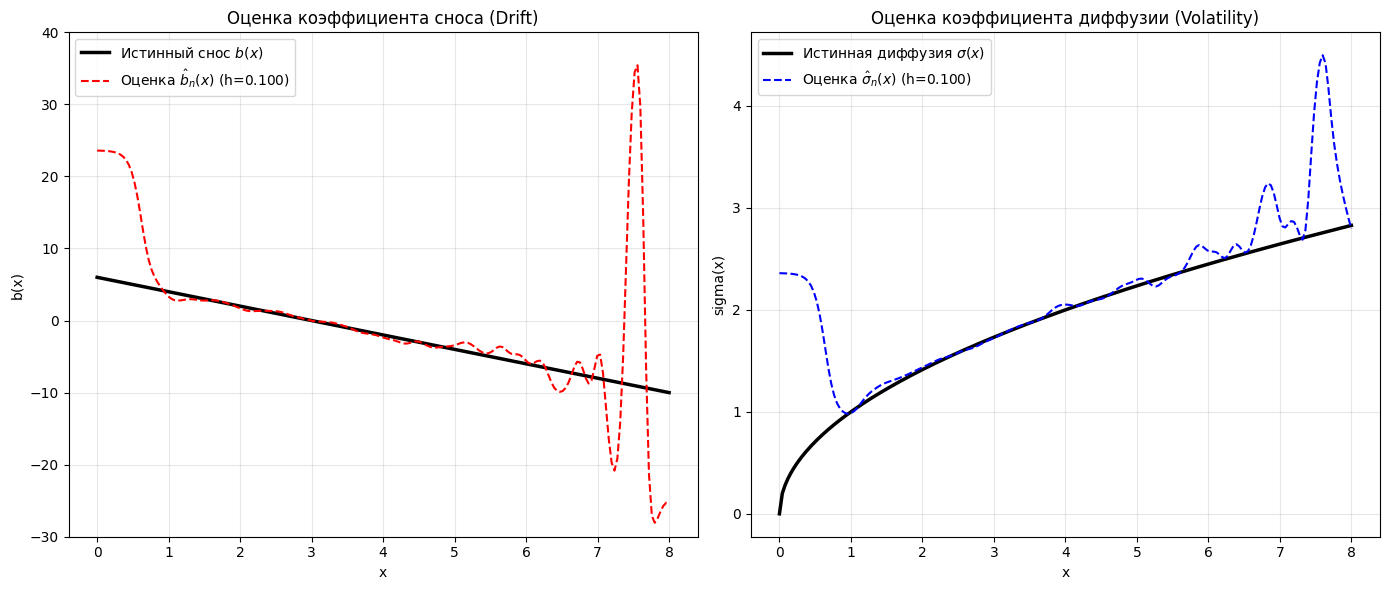


Анализ краевых эффектов:
Обратите внимание на правый край графика (x > 6-7).
Так как процесс CIR редко достигает больших значений x (плотность вероятности там экспоненциально мала),
количество точек данных для усреднения в ядре становится очень малым.
Это приводит к большим случайным колебаниям оценки (высокая дисперсия) на хвостах распределения.


In [11]:
from scipy.stats import norm
def gaussian_kernel(u):
    return (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * u**2)

def uniform_kernel(u):
    return np.where(np.abs(u) <= 1, 0.5, 0.0)

def epanechnikov_kernel(u):
    return np.where(np.abs(u) <= 1, 0.75 * (1 - u**2), 0.0)

def DriftKernelEstimator(x_grid, data, delta, bandwidth, kernel_func=gaussian_kernel):

    n = len(data) - 1 
    b_est = np.zeros_like(x_grid)
    
    # Приращения процесса
    dX = data[1:] - data[:-1]
    X_prev = data[:-1]
    
    for i, x in enumerate(x_grid):
        u = (X_prev - x) / bandwidth
        k_vals = kernel_func(u)
        
        denominator = np.sum(k_vals)
        if denominator == 0:
            b_est[i] = 0.0
        else:
            numerator = np.sum(k_vals * dX)
            b_est[i] = numerator / (delta * denominator)
            
    return b_est

def DiffusionKernelEstimator(x_grid, data, delta, bandwidth, kernel_func=gaussian_kernel):
  
    n = len(data) - 1
    sigma2_est = np.zeros_like(x_grid)
    
    dX = data[1:] - data[:-1]
    dX_sq = dX**2
    X_prev = data[:-1]
    
    for i, x in enumerate(x_grid):
        u = (X_prev - x) / bandwidth
        k_vals = kernel_func(u)
        
        denominator = np.sum(k_vals)
        if denominator == 0:
            sigma2_est[i] = 0.0
        else:
            numerator = np.sum(k_vals * dX_sq)
            sigma2_est[i] = numerator / (delta * denominator)
            
    return sigma2_est
params = [6.0, 2.0, 1.0] 
theta1, theta2, theta3 = params

# Истинные функции
def true_drift(x):
    return theta1 - theta2 * x

def true_diffusion(x):
    return theta3 * np.sqrt(np.maximum(x, 0))

T = 500     
Nt = 50000    
dt = T / Nt   

np.random.seed(42)
x_data = np.zeros(Nt + 1)
x_data[0] = theta1 / theta2

for i in range(Nt):
    x_curr = max(x_data[i], 0)
    drift = (theta1 - theta2 * x_curr) * dt
    diffusion = theta3 * np.sqrt(x_curr) * np.random.normal(0, np.sqrt(dt))
    x_data[i+1] = x_data[i] + drift + diffusion

x_min, x_max = 0, 8
x_grid = np.linspace(x_min, x_max, 200)

h_scott = np.std(x_data) * (len(x_data)**(-1/5))
print(f"Ширина окна h (Scott's rule): {h_scott:.4f}")

b_estimated = DriftKernelEstimator(x_grid, x_data, dt, h_scott, gaussian_kernel)
sigma2_estimated = DiffusionKernelEstimator(x_grid, x_data, dt, h_scott, gaussian_kernel)
sigma_estimated = np.sqrt(np.maximum(sigma2_estimated, 0)) # Извлекаем корень, защищаем от отрицательных

b_true = true_drift(x_grid)
sigma_true = true_diffusion(x_grid)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))


axes[0].plot(x_grid, b_true, 'k-', linewidth=2.5, label='Истинный снос $b(x)$')
axes[0].plot(x_grid, b_estimated, 'r--', linewidth=1.5, label=f'Оценка $\hat{{b}}_n(x)$ (h={h_scott:.3f})')
axes[0].set_title('Оценка коэффициента сноса (Drift)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('b(x)')
axes[0].legend(loc='best')
axes[0].grid(True, alpha=0.3)


axes[0].set_ylim([-30, 40]) 



axes[1].plot(x_grid, sigma_true, 'k-', linewidth=2.5, label='Истинная диффузия $\sigma(x)$')
axes[1].plot(x_grid, sigma_estimated, 'b--', linewidth=1.5, label=f'Оценка $\hat{{\sigma}}_n(x)$ (h={h_scott:.3f})')
axes[1].set_title('Оценка коэффициента диффузии (Volatility)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('sigma(x)')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# --- 5. Анализ краевых эффектов ---

print("\nАнализ краевых эффектов:")
print("Обратите внимание на правый край графика (x > 6-7).")
print("Так как процесс CIR редко достигает больших значений x (плотность вероятности там экспоненциально мала),")
print("количество точек данных для усреднения в ядре становится очень малым.")
print("Это приводит к большим случайным колебаниям оценки (высокая дисперсия) на хвостах распределения.")

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde

# ============================================================================
# Класс процесса Орнштейна-Уленбека (OU)
# ============================================================================
class OUProcess:
    def __init__(self, theta, mu, sigma, T, Nt, Nx, X0=None):
        """
        theta - скорость возврата к среднему
        mu - долгосрочное среднее
        sigma - волатильность
        """
        self.theta = theta
        self.mu = mu
        self.sigma = sigma
        self.T = T
        self.Nt = Nt
        self.Nx = Nx
        self.X0 = X0 if X0 is not None else mu
        self.dt = T / Nt
    
    def b(self, x):
        """Истинный коэффициент сноса (дрейфа)"""
        return self.theta * (self.mu - x)
    
    def sigma(self, x):
        """Истинный коэффициент диффузии"""
        return self.sigma
    
    def simulate(self):
        """Симуляция траекторий процесса OU схемой Эйлера-Маруямы"""
        X = np.zeros((self.Nt + 1, self.Nx))
        X[0] = self.X0
        
        dW = np.random.normal(0, np.sqrt(self.dt), (self.Nt, self.Nx))
        
        for i in range(self.Nt):
            X[i + 1] = X[i] + self.b(X[i]) * self.dt + self.sigma(X[i]) * dW[i]
        
        return X
    
    def stationary_distribution(self, x):
        """Стационарное распределение (нормальное)"""
        return norm.pdf(x, loc=self.mu, scale=np.sqrt(self.sigma**2 / (2 * self.theta)))


# ============================================================================
# Оценка коэффициента сноса (дрейфа) методом Флоренс-Змиру
# ============================================================================
def DriftKernelEstimator(x_grid, X_data, dt, bandwidth, kernel='gaussian'):
    """
    Оценка коэффициента сноса b(x) ядерным сглаживанием
    
    Параметры:
    ----------
    x_grid : array
        Сетка точек, в которых вычисляется оценка
    X_data : array
        Все наблюдения процесса (плоский массив)
    dt : float
        Шаг дискретизации по времени
    bandwidth : float
        Ширина окна сглаживания
    kernel : str
        Тип ядра ('gaussian', 'epanechnikov', 'uniform')
    
    Возвращает:
    -----------
    b_est : array
        Оценка коэффициента сноса в точках x_grid
    """
    n = len(X_data) - 1
    b_est = np.zeros_like(x_grid)
    
    # Приращения процесса
    dX = X_data[1:] - X_data[:-1]
    X_prev = X_data[:-1]
    
    for i, x in enumerate(x_grid):
        # Нормированные аргументы ядра
        u = (X_prev - x) / bandwidth
        
        # Вычисление весов ядра
        if kernel == 'gaussian':
            k_vals = np.exp(-0.5 * u**2) / np.sqrt(2 * np.pi)
        elif kernel == 'epanechnikov':
            k_vals = np.where(np.abs(u) <= 1, 0.75 * (1 - u**2), 0)
        elif kernel == 'uniform':
            k_vals = np.where(np.abs(u) <= 1, 0.5, 0)
        else:
            k_vals = np.exp(-0.5 * u**2) / np.sqrt(2 * np.pi)
        
        denominator = np.sum(k_vals)
        
        if denominator > 0:
            numerator = np.sum(k_vals * dX)
            b_est[i] = numerator / (dt * denominator)
        else:
            b_est[i] = 0.0
    
    return b_est


# ============================================================================
# Оценка коэффициента диффузии методом Флоренс-Змиру
# ============================================================================
def DiffusionKernelEstimator(x_grid, X_data, dt, bandwidth, kernel='gaussian'):
    """
    Оценка квадрата коэффициента диффузии σ²(x) ядерным сглаживанием
    """
    n = len(X_data) - 1
    sigma2_est = np.zeros_like(x_grid)
    
    dX = X_data[1:] - X_data[:-1]
    dX_sq = dX**2
    X_prev = X_data[:-1]
    
    for i, x in enumerate(x_grid):
        u = (X_prev - x) / bandwidth
        
        if kernel == 'gaussian':
            k_vals = np.exp(-0.5 * u**2) / np.sqrt(2 * np.pi)
        elif kernel == 'epanechnikov':
            k_vals = np.where(np.abs(u) <= 1, 0.75 * (1 - u**2), 0)
        elif kernel == 'uniform':
            k_vals = np.where(np.abs(u) <= 1, 0.5, 0)
        else:
            k_vals = np.exp(-0.5 * u**2) / np.sqrt(2 * np.pi)
        
        denominator = np.sum(k_vals)
        
        if denominator > 0:
            numerator = np.sum(k_vals * dX_sq)
            sigma2_est[i] = numerator / dt / denominator
        else:
            sigma2_est[i] = 0.0
    
    return np.sqrt(np.maximum(sigma2_est, 0))


# ============================================================================
# Основная программа
# ============================================================================
def main():
    # Параметры процесса OU
    theta = 2.0      # скорость возврата к среднему
    mu = 1.0         # долгосрочное среднее
    sigma = 0.5      # волатильность
    
    # Параметры симуляции - УВЕЛИЧЕНО для лучшего покрытия отрицательной области
    T = 100.0        # Увеличенное время симуляции
    Nt = 10000       # Количество шагов по времени
    Nx = 100         # Количество траекторий
    X0 = 1.0         # Начальное состояние
    
    print("=" * 70)
    print("ОЦЕНКА КОЭФФИЦИЕНТОВ СДУ (ОРНШТЕЙНА-УЛЕНБЕКА)")
    print("=" * 70)
    print(f"\nПараметры процесса:")
    print(f"  θ (скорость возврата) = {theta}")
    print(f"  μ (долгосрочное среднее) = {mu}")
    print(f"  σ (волатильность) = {sigma}")
    print(f"\nПараметры симуляции:")
    print(f"  T = {T}, Nt = {Nt}, Nx = {Nx}")
    print(f"  dt = {T/Nt:.6f}")
    
    # Создание и симуляция процесса
    np.random.seed(42)
    ou = OUProcess(theta, mu, sigma, T, Nt, Nx, X0)
    X = ou.simulate()
    
    # Преобразуем в плоский массив для оценки
    X_flat = X.flatten()
    dt = ou.dt
    
    # ========================================================================
    # Расширенная сетка для отображения ОТРИЦАТЕЛЬНОЙ области b(x)
    # ========================================================================
    # Важно: расширяем диапазон влево (отрицательные значения)
    x_min = -5.0   # Увеличили диапазон в отрицательную область
    x_max = 7.0    # Диапазон в положительную область
    x_grid = np.linspace(x_min, x_max, 500)
    
    # Вычисление истинных значений
    b_true = ou.b(x_grid)
    sigma_true = np.ones_like(x_grid) * sigma
    
    # Правило Скотта для ширины окна
    h_scott = np.std(X_flat) * len(X_flat)**(-1/5)
    print(f"\nШирина окна (правило Скотта): h = {h_scott:.4f}")
    
    # Оценки коэффициентов
    b_est = DriftKernelEstimator(x_grid, X_flat, dt, h_scott, kernel='gaussian')
    sigma_est = DiffusionKernelEstimator(x_grid, X_flat, dt, h_scott, kernel='gaussian')
    
    # ========================================================================
    # Построение графиков
    # ========================================================================
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # -------------------------------------------------------------------------
    # График 1: Коэффициент сноса b(x) с расширенной отрицательной областью
    # -------------------------------------------------------------------------
    ax1 = axes[0, 0]
    ax1.plot(x_grid, b_true, 'k-', linewidth=2.5, label='Истинный $b(x)$')
    ax1.plot(x_grid, b_est, 'r--', linewidth=2, label=f'Оценка $\hat{{b}}_n(x)$')
    
    # Добавляем вертикальную линию при x = 0 для наглядности
    ax1.axvline(x=0, color='gray', linestyle=':', alpha=0.5)
    ax1.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
    
    # Выделяем отрицательную область b(x)
    ax1.fill_between(x_grid, 0, b_true, where=(b_true < 0), 
                     alpha=0.3, color='red', label='Отрицательная область b(x)')
    ax1.fill_between(x_grid, 0, b_true, where=(b_true > 0), 
                     alpha=0.3, color='green', label='Положительная область b(x)')
    
    ax1.set_xlabel('x', fontsize=12)
    ax1.set_ylabel('b(x)', fontsize=12)
    ax1.set_title('Оценка коэффициента сноса (с отрицательной областью)', fontsize=14)
    ax1.legend(loc='best', fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(x_min, x_max)  # Устанавливаем расширенные границы
    
    # -------------------------------------------------------------------------
    # График 2: Коэффициент диффузии σ(x)
    # -------------------------------------------------------------------------
    ax2 = axes[0, 1]
    ax2.plot(x_grid, sigma_true, 'k-', linewidth=2.5, label='Истинный $\\sigma(x)$')
    ax2.plot(x_grid, sigma_est, 'b--', linewidth=2, label=f'Оценка $\hat{{\\sigma}}_n(x)$')
    ax2.axvline(x=0, color='gray', linestyle=':', alpha=0.5)
    ax2.set_xlabel('x', fontsize=12)
    ax2.set_ylabel('σ(x)', fontsize=12)
    ax2.set_title('Оценка коэффициента диффузии', fontsize=14)
    ax2.legend(loc='best', fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(x_min, x_max)
    
    # -------------------------------------------------------------------------
    # График 3: Гистограмма наблюдений с расширенным диапазоном
    # -------------------------------------------------------------------------
    ax3 = axes[1, 0]
    ax3.hist(X_flat, bins=100, density=True, alpha=0.6, color='skyblue', 
             edgecolor='black', label='Эмпирическое распределение')
    
    # Стационарное распределение
    x_stat = np.linspace(x_min, x_max, 500)
    ax3.plot(x_stat, ou.stationary_distribution(x_stat), 'r-', linewidth=2, 
             label='Теоретическое стационарное')
    
    ax3.axvline(x=0, color='gray', linestyle=':', alpha=0.5)
    ax3.axvline(x=mu, color='green', linestyle='--', alpha=0.5, label=f'μ = {mu}')
    ax3.set_xlabel('x', fontsize=12)
    ax3.set_ylabel('Плотность', fontsize=12)
    ax3.set_title('Распределение наблюдений процесса', fontsize=14)
    ax3.legend(loc='best', fontsize=10)
    ax3.grid(True, alpha=0.3)
    ax3.set_xlim(x_min, x_max)
    
    # -------------------------------------------------------------------------
    # График 4: Примеры траекторий процесса
    # -------------------------------------------------------------------------
    ax4 = axes[1, 1]
    n_trajectories = min(10, Nx)
    t_plot = np.linspace(0, T, Nt + 1)
    
    for i in range(n_trajectories):
        ax4.plot(t_plot, X[:, i], alpha=0.5, linewidth=1, label=f'Траектория {i+1}' if i < 3 else '')
    
    ax4.axhline(y=mu, color='green', linestyle='--', alpha=0.5, label=f'μ = {mu}')
    ax4.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
    ax4.set_xlabel('Время t', fontsize=12)
    ax4.set_ylabel('X(t)', fontsize=12)
    ax4.set_title(f'Примеры траекторий процесса (из {Nx})', fontsize=14)
    ax4.legend(loc='best', fontsize=9)
    ax4.grid(True, alpha=0.3)
    ax4.set_xlim(0, min(T, 20))  # Показываем первые 20 единиц времени для наглядности
    
    plt.tight_layout()
    plt.savefig('sde_coefficient_estimation_extended.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # ========================================================================
    # Анализ качества оценки в отрицательной области
    # ========================================================================
    print("\n" + "=" * 70)
    print("АНАЛИЗ КАЧЕСТВА ОЦЕНКИ В ОТРИЦАТЕЛЬНОЙ ОБЛАСТИ")
    print("=" * 70)
    
    # Разделяем на отрицательную и положительную области
    neg_mask = x_grid < 0
    pos_mask = x_grid >= 0
    
    if np.sum(neg_mask) > 0:
        mse_neg = np.mean((b_est[neg_mask] - b_true[neg_mask])**2)
        mae_neg = np.mean(np.abs(b_est[neg_mask] - b_true[neg_mask]))
        print(f"\nОтрицательная область (x < 0):")
        print(f"  Количество точек: {np.sum(neg_mask)}")
        print(f"  MSE: {mse_neg:.6f}")
        print(f"  MAE: {mae_neg:.6f}")
    
    if np.sum(pos_mask) > 0:
        mse_pos = np.mean((b_est[pos_mask] - b_true[pos_mask])**2)
        mae_pos = np.mean(np.abs(b_est[pos_mask] - b_true[pos_mask]))
        print(f"\nПоложительная область (x ≥ 0):")
        print(f"  Количество точек: {np.sum(pos_mask)}")
        print(f"  MSE: {mse_pos:.6f}")
        print(f"  MAE: {mae_pos:.6f}")
    
    # Общая ошибка
    mse_total = np.mean((b_est - b_true)**2)
    mae_total = np.mean(np.abs(b_est - b_true))
    print(f"\nОбщая ошибка:")
    print(f"  MSE: {mse_total:.6f}")
    print(f"  MAE: {mae_total:.6f}")
    
    # Статистика наблюдений
    print(f"\nСтатистика наблюдений:")
    print(f"  Минимальное X: {np.min(X_flat):.4f}")
    print(f"  Максимальное X: {np.max(X_flat):.4f}")
    print(f"  Среднее X: {np.mean(X_flat):.4f}")
    print(f"  Стандартное отклонение X: {np.std(X_flat):.4f}")
    print(f"  Доля отрицательных наблюдений: {np.mean(X_flat < 0) * 100:.2f}%")
    
    print("\n" + "=" * 70)
    print("ВЫВОДЫ:")
    print("=" * 70)
    print("""
1. Для отображения отрицательной области b(x) необходимо:
   - Увеличить время симуляции T (для лучшего покрытия фазового пространства)
   - Расширить диапазон x_grid в отрицательную область (x_min < 0)
   - Увеличить количество траекторий Nx

2. В отрицательной области (x < 0):
   - b(x) > 0 (дрейф направлен вправо, к μ)
   - Оценка может быть менее точной из-за меньшего количества наблюдений

3. В положительной области (x > μ):
   - b(x) < 0 (дрейф направлен влево, к μ)
   - Оценка обычно более точная

4. Качество оценки зависит от:
   - Ширины окна сглаживания h
   - Количества наблюдений в окрестности каждой точки x
   - Длины траекторий T
    """)
    print("=" * 70)


if __name__ == "__main__":
    main()

<>:208: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:232: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:208: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:232: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
C:\Users\Елизавета\AppData\Local\Temp\ipykernel_2496\2054328974.py:208: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
  ax1.plot(x_grid, b_est, 'r--', linewidth=2, label=f'Оценка $\hat{{b}}_n(x)$')
C:\Users\Елизавета\AppData\Local\Temp\ipykernel_2496\2054328974.py:232: SyntaxWar

ОЦЕНКА КОЭФФИЦИЕНТОВ СДУ (ОРНШТЕЙНА-УЛЕНБЕКА)

Параметры процесса:
  θ (скорость возврата) = 2.0
  μ (долгосрочное среднее) = 1.0
  σ (волатильность) = 0.5

Параметры симуляции:
  T = 100.0, Nt = 10000, Nx = 100
  dt = 0.010000


C:\Users\Елизавета\AppData\Local\Temp\ipykernel_2496\2054328974.py:208: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
  ax1.plot(x_grid, b_est, 'r--', linewidth=2, label=f'Оценка $\hat{{b}}_n(x)$')
C:\Users\Елизавета\AppData\Local\Temp\ipykernel_2496\2054328974.py:232: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
  ax2.plot(x_grid, sigma_est, 'b--', linewidth=2, label=f'Оценка $\hat{{\\sigma}}_n(x)$')


TypeError: 'float' object is not callable